# Disease Identification POC (Notebook-First)

## Objective
Train and evaluate an initial **multi-label disease identification** model for:
- `AURI`
- `PN`
- `TB`
- `COVID`

This POC fine-tunes and compares transformer models (`mBERT` and `XLM-RoBERTa`), tunes thresholds, evaluates on holdout test data, saves artifacts, and demonstrates inference output.

**Label order contract:** `["AURI", "PN", "TB", "COVID"]`  
**Success metric:** `Micro-F1 >= 0.75`


In [1]:
# Environment setup
import ast
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    precision_recall_fscore_support,
)
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')


In [2]:
# Config
from pathlib import Path

CWD = Path.cwd()
ROOT_DIR = next((p for p in [CWD, *CWD.parents] if (p / '.git').exists()), CWD)

DATA_CANDIDATES = [
    ROOT_DIR / 'Old Model/data/DATASET USED IN MODELS/Merged_dataset.xlsx',
    ROOT_DIR / 'Old Model/data/DATASET USED IN MODELS/Gold_standard_withLANG.xlsx',
]

DATA_PATH = next((p.resolve() for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    tried = '\n'.join(str(p) for p in DATA_CANDIDATES)
    raise FileNotFoundError(
        f'Could not locate expected XLSX dataset from cwd={CWD}. Tried:\n{tried}'
    )

TEST_SIZE = 0.10
VAL_SIZE = 0.10  # fraction of full dataset
LABELS = ['AURI', 'PN', 'TB', 'COVID']
ARTIFACT_DIR = Path('artifacts/poc_transformers')
REPORT_DIR = ROOT_DIR / 'reports' / 'poc_transformers'

MODEL_CANDIDATES = {
    'mbert': 'bert-base-multilingual-cased',
    'xlm_roberta': 'xlm-roberta-base',
}
MAX_LENGTH = 128
BATCH_SIZE = 4
NUM_EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print()
print({
    'cwd': str(CWD),
    'root_dir': str(ROOT_DIR),
    'DATA_PATH': str(DATA_PATH),
    'TEST_SIZE': TEST_SIZE,
    'VAL_SIZE': VAL_SIZE,
    'LABELS': LABELS,
    'ARTIFACT_DIR': str(ARTIFACT_DIR),
    'REPORT_DIR': str(REPORT_DIR),
    'MODEL_CANDIDATES': MODEL_CANDIDATES,
})



{'cwd': '/Users/angelodelapaz/Documents/GitHub/healthphpersonal/notebooks', 'root_dir': '/Users/angelodelapaz/Documents/GitHub/healthphpersonal', 'DATA_PATH': '/Users/angelodelapaz/Documents/GitHub/healthphpersonal/Old Model/data/DATASET USED IN MODELS/Merged_dataset.xlsx', 'TEST_SIZE': 0.1, 'VAL_SIZE': 0.1, 'LABELS': ['AURI', 'PN', 'TB', 'COVID'], 'ARTIFACT_DIR': 'artifacts/poc_transformers', 'REPORT_DIR': '/Users/angelodelapaz/Documents/GitHub/healthphpersonal/reports/poc_transformers', 'MODEL_CANDIDATES': {'mbert': 'bert-base-multilingual-cased', 'xlm_roberta': 'xlm-roberta-base'}}


In [3]:
# Data loading + strict validation (no eval)
def parse_label_vector(value, expected_len=4):
    if not isinstance(value, str):
        raise ValueError(f'annotate must be string; got {type(value)}')

    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError) as exc:
        raise ValueError(f'Invalid annotate literal: {value}') from exc

    if not isinstance(parsed, (list, tuple)):
        raise ValueError(f'annotate must parse to list/tuple: {value}')

    if len(parsed) != expected_len:
        raise ValueError(f'annotate length must be {expected_len}: {value}')

    clean = []
    for item in parsed:
        if item not in (0, 1):
            raise ValueError(f'annotate values must be binary 0/1: {value}')
        clean.append(int(item))

    return clean


def validate_and_prepare(df):
    required_cols = {'post', 'annotate'}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f'Missing required columns: {sorted(missing)}')

    rows = []
    dropped = {
        'empty_post': 0,
        'invalid_annotate': 0,
    }

    for _, row in df.iterrows():
        post = row['post']
        annotate = row['annotate']

        if not isinstance(post, str) or not post.strip():
            dropped['empty_post'] += 1
            continue

        try:
            label_vec = parse_label_vector(annotate, expected_len=len(LABELS))
        except ValueError:
            dropped['invalid_annotate'] += 1
            continue

        rows.append({
            'post': ' '.join(post.split()),
            'annotate': str(label_vec),
            **{label: label_vec[i] for i, label in enumerate(LABELS)},
        })

    clean_df = pd.DataFrame(rows)
    if not clean_df.empty:
        clean_df = clean_df.drop_duplicates(subset=['post']).reset_index(drop=True)

    return clean_df, dropped

raw_df = pd.read_excel(DATA_PATH)
clean_df, dropped_stats = validate_and_prepare(raw_df)

print('Raw rows:', len(raw_df))
print('Clean rows:', len(clean_df))
print('Dropped stats:', dropped_stats)
print('Columns:', clean_df.columns.tolist())


Raw rows: 21968
Clean rows: 6290
Dropped stats: {'empty_post': 0, 'invalid_annotate': 0}
Columns: ['post', 'annotate', 'AURI', 'PN', 'TB', 'COVID']


Row count: 6290

Label counts:
AURI     1272
PN        859
TB        953
COVID    1285
dtype: int64

Label prevalence:
COVID    20.43%
AURI     20.22%
TB       15.15%
PN       13.66%
dtype: str

All-zero label rows: 4661


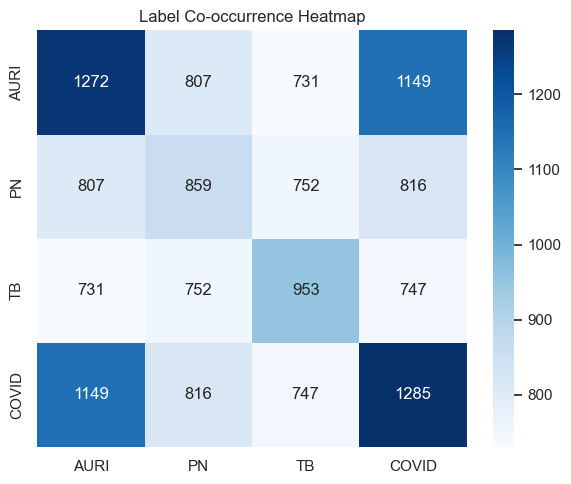

In [4]:
# Quick EDA
print('Row count:', len(clean_df))

label_counts = clean_df[LABELS].sum().astype(int)
label_prevalence = (label_counts / len(clean_df)).sort_values(ascending=False)

print('\nLabel counts:')
print(label_counts)
print('\nLabel prevalence:')
print((label_prevalence * 100).round(2).astype(str) + '%')

all_zero_count = int((clean_df[LABELS].sum(axis=1) == 0).sum())
print('\nAll-zero label rows:', all_zero_count)

cooccurrence = clean_df[LABELS].T.dot(clean_df[LABELS])
plt.figure(figsize=(6, 5))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues')
plt.title('Label Co-occurrence Heatmap')
plt.tight_layout()
plt.show()


In [5]:
# Iterative multi-label stratified split (custom, dependency-free)
def iterative_multilabel_split_indices(y, test_size=0.1, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y, dtype=int)

    n_samples, n_labels = y.shape
    n_test = int(round(n_samples * test_size))
    n_test = max(1, min(n_samples - 1, n_test))

    all_idx = np.arange(n_samples)
    unassigned = set(all_idx.tolist())
    test_idx = []

    target_test_label_counts = y.sum(axis=0) * test_size
    current_test_label_counts = np.zeros(n_labels, dtype=float)

    sample_label_counts = y.sum(axis=1)

    while len(test_idx) < n_test and unassigned:
        deficits = target_test_label_counts - current_test_label_counts
        deficits = np.where(deficits > 0, deficits, 0)

        if deficits.sum() == 0:
            remaining = np.array(list(unassigned))
            rng.shuffle(remaining)
            take = remaining[: (n_test - len(test_idx))]
            test_idx.extend(take.tolist())
            break

        label_order = np.argsort(-deficits)
        chosen = None

        for label in label_order:
            candidates = [i for i in unassigned if y[i, label] == 1]
            if not candidates:
                continue

            min_card = min(sample_label_counts[candidates])
            filtered = [i for i in candidates if sample_label_counts[i] == min_card]
            chosen = int(rng.choice(filtered))
            break

        if chosen is None:
            chosen = int(rng.choice(np.array(list(unassigned))))

        test_idx.append(chosen)
        unassigned.remove(chosen)
        current_test_label_counts += y[chosen]

    test_idx = np.array(sorted(set(test_idx)))
    train_idx = np.array(sorted(list(set(all_idx) - set(test_idx))))
    return train_idx, test_idx


def build_splits(df, labels, test_size=0.1, val_size=0.1, random_state=42):
    y_all = df[labels].values

    trainval_idx, test_idx = iterative_multilabel_split_indices(
        y_all, test_size=test_size, random_state=random_state
    )

    trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)

    y_trainval = trainval_df[labels].values
    val_relative = val_size / (1.0 - test_size)

    train_idx_local, val_idx_local = iterative_multilabel_split_indices(
        y_trainval, test_size=val_relative, random_state=random_state
    )

    train_df = trainval_df.iloc[train_idx_local].reset_index(drop=True)
    val_df = trainval_df.iloc[val_idx_local].reset_index(drop=True)

    return train_df, val_df, test_df

train_df, val_df, test_df = build_splits(
    clean_df,
    labels=LABELS,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=SEED,
)

print('Split sizes:')
print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))
print('total check:', len(train_df) + len(val_df) + len(test_df), '==', len(clean_df))

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    prevalence = (part[LABELS].mean() * 100).round(2)
    print(f"\n{name} label prevalence (%)")
    print(prevalence.to_dict())



Split sizes:
train: 5032 val: 629 test: 629
total check: 6290 == 6290

train label prevalence (%)
{'AURI': 17.69, 'PN': 11.92, 'TB': 13.29, 'COVID': 17.75}

val label prevalence (%)
{'AURI': 31.64, 'PN': 21.3, 'TB': 23.21, 'COVID': 32.59}

test label prevalence (%)
{'AURI': 29.09, 'PN': 19.87, 'TB': 21.94, 'COVID': 29.73}


In [8]:
# Transformer training setup (shared)
import gc

y_train = train_df[LABELS].values.astype(np.float32)
y_val = val_df[LABELS].values.astype(np.float32)
y_test = test_df[LABELS].values.astype(np.float32)


class MultiLabelTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = ' '.join(str(self.texts[idx]).split())
        encoded = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt',
        )
        item = {k: v.squeeze(0) for k, v in encoded.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item


def sigmoid_logits(logits):
    return 1 / (1 + np.exp(-logits))


def compute_eval_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid_logits(logits)
    preds = (probs >= 0.5).astype(int)
    labels = labels.astype(int)

    return {
        'micro_f1': float(f1_score(labels, preds, average='micro', zero_division=0)),
        'macro_f1': float(f1_score(labels, preds, average='macro', zero_division=0)),
        'hamming_loss': float(hamming_loss(labels, preds)),
    }


def clear_device_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        torch.mps.empty_cache()


def train_single_transformer(model_key, pretrained_name):
    print(f'\n=== Training {model_key}: {pretrained_name} ===')
    clear_device_cache()

    model_artifact_dir = ARTIFACT_DIR / model_key
    model_dir = model_artifact_dir / 'model'
    trainer_output_dir = model_artifact_dir / 'trainer_output'
    model_artifact_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(pretrained_name, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained_name,
        num_labels=len(LABELS),
        problem_type='multi_label_classification',
    )

    train_ds = MultiLabelTextDataset(train_df['post'], y_train, tokenizer, max_length=MAX_LENGTH)
    val_ds = MultiLabelTextDataset(val_df['post'], y_val, tokenizer, max_length=MAX_LENGTH)
    test_ds = MultiLabelTextDataset(test_df['post'], y_test, tokenizer, max_length=MAX_LENGTH)

    training_args = TrainingArguments(
        output_dir=str(trainer_output_dir),
        eval_strategy='epoch',
        save_strategy='epoch',
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model='eval_micro_f1',
        greater_is_better=True,
        logging_steps=25,
        save_total_limit=1,
        gradient_checkpointing=True,
        report_to='none',
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_eval_metrics,
    )

    trainer.train()

    val_logits = trainer.predict(val_ds).predictions
    test_logits = trainer.predict(test_ds).predictions

    trainer.model.save_pretrained(model_dir)
    tokenizer.save_pretrained(model_dir)

    run_result = {
        'model_key': model_key,
        'pretrained_name': pretrained_name,
        'model_dir': str(model_dir),
        'val_proba': sigmoid_logits(val_logits),
        'test_proba': sigmoid_logits(test_logits),
    }

    del trainer, model, tokenizer, train_ds, val_ds, test_ds, val_logits, test_logits
    clear_device_cache()

    return run_result


trained_runs = {}


In [9]:
# Train mBERT
model_key = 'mbert'
trained_runs[model_key] = train_single_transformer(model_key, MODEL_CANDIDATES[model_key])



=== Training mbert: bert-base-multilingual-cased ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/angelodelapaz/Docum

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.358769,0.625142,0.480458,0.478029,0.216614,8.881200,70.823000,17.790000
2,0.156117,0.576616,0.586826,0.574327,0.191971,10.260200,61.305000,15.399000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/angelodelapaz/Documents/GitHub/healthphpersonal/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

/Users/angelodelapaz/Documents/GitHub/healthphpersonal/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
# Train XLM-RoBERTa
model_key = 'xlm_roberta'
trained_runs[model_key] = train_single_transformer(model_key, MODEL_CANDIDATES[model_key])

print('Completed transformer training for:', list(trained_runs.keys()))



=== Training xlm_roberta: xlm-roberta-base ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/angelodelapaz/Documents/GitHub/healthphpersonal/.venv/lib/python3.14/site-packages/torch/utils/data/da

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.377481,0.670294,0.482422,0.475483,0.210652,11.300300,55.662000,13.982000
2,0.225724,0.540582,0.587832,0.582145,0.191176,11.380800,55.269000,13.883000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

/Users/angelodelapaz/Documents/GitHub/healthphpersonal/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Completed transformer training for: ['mbert', 'xlm_roberta']


In [12]:
# Validation threshold tuning (per label, per transformer model)
def tune_thresholds(y_true, y_proba, labels, start=0.10, stop=0.90, step=0.01):
    thresholds = {}
    details = {}
    grid = np.arange(start, stop + 1e-9, step)

    for i, label in enumerate(labels):
        best_t = 0.5
        best_f1 = -1.0

        for t in grid:
            pred = (y_proba[:, i] >= t).astype(int)
            p, r, f1, _ = precision_recall_fscore_support(
                y_true[:, i], pred, average='binary', zero_division=0
            )
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(np.round(t, 4))
                best_p, best_r = p, r

        thresholds[label] = best_t
        details[label] = {
            'precision': float(best_p),
            'recall': float(best_r),
            'f1': float(best_f1),
        }

    return thresholds, details


def apply_thresholds(y_proba, thresholds, labels):
    out = np.zeros_like(y_proba, dtype=int)
    for i, label in enumerate(labels):
        out[:, i] = (y_proba[:, i] >= thresholds[label]).astype(int)
    return out


def compute_metrics(y_true, y_pred, labels):
    micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    ham = hamming_loss(y_true, y_pred)
    exact = float(np.mean(np.all(y_true == y_pred, axis=1)))

    per_label = {}
    for i, label in enumerate(labels):
        p, r, f1, _ = precision_recall_fscore_support(
            y_true[:, i], y_pred[:, i], average='binary', zero_division=0
        )
        per_label[label] = {
            'precision': float(p),
            'recall': float(r),
            'f1': float(f1),
        }

    return {
        'micro_f1': float(micro),
        'macro_f1': float(macro),
        'hamming_loss': float(ham),
        'exact_match_ratio': exact,
        'per_label': per_label,
    }


model_thresholds = {}
model_val_metrics = {}

for model_key, run in trained_runs.items():
    thresholds, val_label_metrics = tune_thresholds(y_val.astype(int), run['val_proba'], LABELS)
    y_val_pred = apply_thresholds(run['val_proba'], thresholds, LABELS)
    val_metrics = compute_metrics(y_val.astype(int), y_val_pred, LABELS)

    model_thresholds[model_key] = thresholds
    model_val_metrics[model_key] = {
        'thresholds': thresholds,
        'per_label_threshold_f1': val_label_metrics,
        'metrics': val_metrics,
    }

print('Validation metrics by model:')
print(json.dumps({k: v['metrics'] for k, v in model_val_metrics.items()}, indent=2))


Validation metrics by model:
{
  "mbert": {
    "micro_f1": 0.6425339366515838,
    "macro_f1": 0.6346182308739927,
    "hamming_loss": 0.18839427662957076,
    "exact_match_ratio": 0.6359300476947536,
    "per_label": {
      "AURI": {
        "precision": 0.7344632768361582,
        "recall": 0.6532663316582915,
        "f1": 0.6914893617021277
      },
      "PN": {
        "precision": 0.6136363636363636,
        "recall": 0.6044776119402985,
        "f1": 0.6090225563909775
      },
      "TB": {
        "precision": 0.5364238410596026,
        "recall": 0.5547945205479452,
        "f1": 0.5454545454545454
      },
      "COVID": {
        "precision": 0.7362637362637363,
        "recall": 0.6536585365853659,
        "f1": 0.6925064599483204
      }
    }
  },
  "xlm_roberta": {
    "micro_f1": 0.658753709198813,
    "macro_f1": 0.6507040437322253,
    "hamming_loss": 0.18282988871224165,
    "exact_match_ratio": 0.6391096979332274,
    "per_label": {
      "AURI": {
        "prec

In [13]:
# Final test evaluation + select best transformer model
model_test_results = {}

for model_key, run in trained_runs.items():
    thresholds = model_thresholds[model_key]
    y_test_pred_model = apply_thresholds(run['test_proba'], thresholds, LABELS)
    metrics_model = compute_metrics(y_test.astype(int), y_test_pred_model, LABELS)

    model_test_results[model_key] = {
        'thresholds': thresholds,
        'metrics': metrics_model,
    }

print('Test metrics by model:')
print(json.dumps({k: v['metrics'] for k, v in model_test_results.items()}, indent=2))

best_model_key = max(
    model_test_results.keys(),
    key=lambda k: model_test_results[k]['metrics']['micro_f1'],
)
best_run = trained_runs[best_model_key]

model = AutoModelForSequenceClassification.from_pretrained(best_run['model_dir'])
tokenizer = AutoTokenizer.from_pretrained(best_run['model_dir'], use_fast=True)
test_proba = best_run['test_proba']
thresholds = model_test_results[best_model_key]['thresholds']
y_test_pred = apply_thresholds(test_proba, thresholds, LABELS)
metrics = model_test_results[best_model_key]['metrics']

print(f'\nSelected best model: {best_model_key} ({best_run["pretrained_name"]})')
print('Selected model test metrics:')
print(json.dumps(metrics, indent=2))

success = metrics['micro_f1'] >= 0.75
print('\nSUCCESS GATE (Micro-F1 >= 0.75):', 'PASS' if success else 'FAIL')


Test metrics by model:
{
  "mbert": {
    "micro_f1": 0.4540622627182992,
    "macro_f1": 0.4425677949121861,
    "hamming_loss": 0.2857710651828299,
    "exact_match_ratio": 0.3767885532591415,
    "per_label": {
      "AURI": {
        "precision": 0.5445026178010471,
        "recall": 0.5683060109289617,
        "f1": 0.5561497326203209
      },
      "PN": {
        "precision": 0.366412213740458,
        "recall": 0.384,
        "f1": 0.375
      },
      "TB": {
        "precision": 0.3271604938271605,
        "recall": 0.38405797101449274,
        "f1": 0.35333333333333333
      },
      "COVID": {
        "precision": 0.47,
        "recall": 0.5026737967914439,
        "f1": 0.48578811369509045
      }
    }
  },
  "xlm_roberta": {
    "micro_f1": 0.46956521739130436,
    "macro_f1": 0.46039515405167547,
    "hamming_loss": 0.26669316375198726,
    "exact_match_ratio": 0.383147853736089,
    "per_label": {
      "AURI": {
        "precision": 0.6292134831460674,
        "recall

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Selected best model: xlm_roberta (xlm-roberta-base)
Selected model test metrics:
{
  "micro_f1": 0.46956521739130436,
  "macro_f1": 0.46039515405167547,
  "hamming_loss": 0.26669316375198726,
  "exact_match_ratio": 0.383147853736089,
  "per_label": {
    "AURI": {
      "precision": 0.6292134831460674,
      "recall": 0.6120218579234973,
      "f1": 0.6204986149584487
    },
    "PN": {
      "precision": 0.4336283185840708,
      "recall": 0.392,
      "f1": 0.4117647058823529
    },
    "TB": {
      "precision": 0.3333333333333333,
      "recall": 0.39855072463768115,
      "f1": 0.36303630363036304
    },
    "COVID": {
      "precision": 0.4602272727272727,
      "recall": 0.43315508021390375,
      "f1": 0.4462809917355372
    }
  }
}

SUCCESS GATE (Micro-F1 >= 0.75): FAIL


In [14]:
# Save artifacts + reports
best_model_dir = ARTIFACT_DIR / 'best_model'
best_model_dir.mkdir(parents=True, exist_ok=True)

model.save_pretrained(best_model_dir)
tokenizer.save_pretrained(best_model_dir)

with open(ARTIFACT_DIR / 'thresholds.json', 'w', encoding='utf-8') as f:
    json.dump(thresholds, f, indent=2)

with open(ARTIFACT_DIR / 'label_order.json', 'w', encoding='utf-8') as f:
    json.dump(LABELS, f, indent=2)

best_model_info = {
    'best_model_key': best_model_key,
    'pretrained_name': trained_runs[best_model_key]['pretrained_name'],
    'model_dir': trained_runs[best_model_key]['model_dir'],
}
with open(ARTIFACT_DIR / 'best_model_info.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_info, f, indent=2)

metrics_payload = {
    'label_order': LABELS,
    'selected_model': best_model_info,
    'thresholds': thresholds,
    'metrics': metrics,
    'success_micro_f1_ge_0_75': bool(metrics['micro_f1'] >= 0.75),
}

with open(REPORT_DIR / 'poc_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2)

with open(REPORT_DIR / 'poc_transformer_model_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            model_key: {
                'pretrained_name': trained_runs[model_key]['pretrained_name'],
                'validation': model_val_metrics[model_key],
                'test': model_test_results[model_key],
            }
            for model_key in model_test_results
        },
        f,
        indent=2,
    )

# Error samples
rows = []
for i in range(len(test_df)):
    if not np.array_equal(y_test[i].astype(int), y_test_pred[i]):
        probs = {label: float(test_proba[i, j]) for j, label in enumerate(LABELS)}
        true_labels = [label for j, label in enumerate(LABELS) if int(y_test[i, j]) == 1]
        pred_labels = [label for j, label in enumerate(LABELS) if y_test_pred[i, j] == 1]
        rows.append({
            'post': test_df.iloc[i]['post'],
            'true_labels': ','.join(true_labels) if true_labels else 'NONE',
            'pred_labels': ','.join(pred_labels) if pred_labels else 'NONE',
            'probabilities': json.dumps(probs),
        })

error_df = pd.DataFrame(rows)
error_df.to_csv(REPORT_DIR / 'poc_error_samples.csv', index=False)

print('Saved selected model artifacts to', best_model_dir)
print('Saved reports to', REPORT_DIR)
print('Error samples:', len(error_df))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved selected model artifacts to artifacts/poc_transformers/best_model
Saved reports to /Users/angelodelapaz/Documents/GitHub/healthphpersonal/reports/poc_transformers
Error samples: 388


In [15]:
# Inference demo function (contract: labels + probabilities + thresholds_used)
model.eval()


def predict_disease_labels(text):
    if not isinstance(text, str) or not text.strip():
        raise ValueError('text must be a non-empty string')

    clean_text = ' '.join(text.split())
    encoded = tokenizer(
        clean_text,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt',
    )

    device = next(model.parameters()).device
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        logits = model(**encoded).logits

    proba = torch.sigmoid(logits).cpu().numpy()[0]

    probabilities = {label: float(proba[i]) for i, label in enumerate(LABELS)}
    labels = [label for i, label in enumerate(LABELS) if proba[i] >= thresholds[label]]

    return {
        'labels': labels,
        'probabilities': probabilities,
        'thresholds_used': thresholds,
    }


examples = [
    'I have fever, dry cough, and sore throat for 2 days.',
    'ubong may dugo at hirap huminga ako nitong gabi',
    'feeling okay, no symptoms today',
]

for text in examples:
    print('\nINPUT:', text)
    print(json.dumps(predict_disease_labels(text), indent=2))



INPUT: I have fever, dry cough, and sore throat for 2 days.
{
  "labels": [
    "AURI",
    "TB",
    "COVID"
  ],
  "probabilities": {
    "AURI": 0.22293047606945038,
    "PN": 0.11446201801300049,
    "TB": 0.17397409677505493,
    "COVID": 0.21449820697307587
  },
  "thresholds_used": {
    "AURI": 0.11,
    "PN": 0.12,
    "TB": 0.1,
    "COVID": 0.11
  }
}

INPUT: ubong may dugo at hirap huminga ako nitong gabi
{
  "labels": [
    "AURI",
    "PN",
    "TB",
    "COVID"
  ],
  "probabilities": {
    "AURI": 0.9512234926223755,
    "PN": 0.8087509870529175,
    "TB": 0.8294640779495239,
    "COVID": 0.9540141224861145
  },
  "thresholds_used": {
    "AURI": 0.11,
    "PN": 0.12,
    "TB": 0.1,
    "COVID": 0.11
  }
}

INPUT: feeling okay, no symptoms today
{
  "labels": [
    "AURI",
    "TB",
    "COVID"
  ],
  "probabilities": {
    "AURI": 0.13807587325572968,
    "PN": 0.06578832119703293,
    "TB": 0.10987868160009384,
    "COVID": 0.12753593921661377
  },
  "thresholds_used

In [16]:
# Test cases and scenario checks
# 1) Parser rejects malformed label strings
bad_inputs = ['notalist', '[1,0,1]', '[1,2,0,1]', '[1,0,0,0,1]']
for bad in bad_inputs:
    try:
        parse_label_vector(bad)
        raise AssertionError(f'Expected parse failure for: {bad}')
    except ValueError:
        pass

# 2) Split reproducibility check (same seed => same posts)
train_df_2, val_df_2, test_df_2 = build_splits(
    clean_df,
    labels=LABELS,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=SEED,
)
assert train_df['post'].tolist() == train_df_2['post'].tolist()
assert val_df['post'].tolist() == val_df_2['post'].tolist()
assert test_df['post'].tolist() == test_df_2['post'].tolist()

# 3) Threshold JSON contract
with open(ARTIFACT_DIR / 'thresholds.json', 'r', encoding='utf-8') as f:
    loaded_thresholds = json.load(f)
assert list(loaded_thresholds.keys()) == LABELS

# 4) Inference schema checks
res_none = predict_disease_labels('random harmless text without symptoms')
res_single = predict_disease_labels('fever and dry cough only')
res_multi = predict_disease_labels('ubo, lagnat, hirap huminga, chest pain')

for res in [res_none, res_single, res_multi]:
    assert set(res.keys()) == {'labels', 'probabilities', 'thresholds_used'}
    assert set(res['probabilities'].keys()) == set(LABELS)
    assert set(res['thresholds_used'].keys()) == set(LABELS)
    assert isinstance(res['labels'], list)

# 5) End-to-end rerun readiness checks (artifacts present)
required_paths = [
    ARTIFACT_DIR / 'best_model' / 'config.json',
    ARTIFACT_DIR / 'best_model' / 'tokenizer_config.json',
    ARTIFACT_DIR / 'label_order.json',
    ARTIFACT_DIR / 'best_model_info.json',
    ARTIFACT_DIR / 'thresholds.json',
    REPORT_DIR / 'poc_metrics.json',
    REPORT_DIR / 'poc_error_samples.csv',
    REPORT_DIR / 'poc_transformer_model_comparison.json',
]
missing_paths = [str(p) for p in required_paths if not p.exists()]
assert not missing_paths, f'Missing outputs: {missing_paths}'

weight_candidates = [
    ARTIFACT_DIR / 'best_model' / 'model.safetensors',
    ARTIFACT_DIR / 'best_model' / 'pytorch_model.bin',
]
assert any(p.exists() for p in weight_candidates), 'Missing transformer model weights.'

print('All POC tests passed.')


All POC tests passed.
